# 📊 **TelecomX - Análise de Evasão de Clientes - Parte 2**
#### ***Challenge Data Science | Alura + Oracle Next Education (ONE)***

- 👤 **Autor:** Lucas Rodrigues
- 📅 **Data:** 04 de Março de 2026
- 🔗 **Repositório:** GitHub - telecomx-churn-analysis
- 🎯 **Objetivo:** Desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços. A empresa quer antecipar o problema da evasão, e cabe a você construir um pipeline robusto para essa etapa inicial de modelagem.

---
### 🏢 1. CONTEXTO DO NEGÓCIO



 Você foi promovido após seu excelente desempenho na análise exploratória da evasão de clientes na Telecom X. Sua dedicação, clareza na comunicação dos dados e visão estratégica fizeram a diferença.

 Agora, você foi convidado a integrar oficialmente a equipe de Machine Learning da empresa!

 Meu desafio será:

- **Preparar** os dados para a modelagem (tratamento, encoding, normalização).

- **Realizar** análise de correlação e seleção de variáveis.

- **Treinar** dois ou mais modelos de classificação.

- **Avaliar** o desempenho dos modelos com métricas.

- **Interpretar** os resultados, incluindo a importância das variáveis.

- **Criar** uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

___
### 📦 2. DEPENDÊNCIAS DO PROJETO

| Biblioteca       | Versão   |
|------------------|----------|
| matplotlib       | 3.10.8   |
| numpy            | 2.4.2    |
| pandas           | 3.0.1    |
| scikit-learn     | 1.8.0    |
| seaborn         | 0.13.2   |

In [87]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


## Importando os Dados

#### Explorando os dados

In [88]:
dados = pd.read_csv('dados_normalizados_ml.csv')
dados.head()

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
0,0,feminino,0,1,1,9,1,0,dsl,0,...,0,1,1,0,anual,1,cheque_correio,65.6,593.30,2.19
1,0,masculino,0,0,0,9,1,1,dsl,0,...,0,0,0,1,mensal,0,cheque_correio,59.9,542.40,2.00
2,1,masculino,0,0,0,4,1,0,fibra_optica,0,...,1,0,0,0,mensal,1,cheque_eletronico,73.9,280.85,2.46
3,1,masculino,1,1,0,13,1,0,fibra_optica,0,...,1,0,1,1,mensal,1,cheque_eletronico,98.0,1237.85,3.27
4,1,feminino,1,1,0,3,1,0,fibra_optica,0,...,0,1,1,0,mensal,1,cheque_correio,83.9,267.40,2.80


In [89]:
dados.describe()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,fatura_digital,cobranca_mensal,cobranca_total,cobranca_diaria
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213,2.157292
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [90]:
dados.describe(include='O')

C:\Users\User\AppData\Local\Temp\ipykernel_15644\3502782009.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dados.describe(include='O')


,genero,tipo_internet,tipo_contrato,metodo_pagamento
count,7267,7267,7267,7267
unique,2,3,3,4
top,masculino,fibra_optica,mensal,cheque_eletronico
freq,3675,3198,4005,2445


In [91]:
dados.shape

(7267, 21)

In [92]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   evasao                7267 non-null   int64  
 1   genero                7267 non-null   str    
 2   idoso                 7267 non-null   int64  
 3   possui_parceiro       7267 non-null   int64  
 4   possui_dependentes    7267 non-null   int64  
 5   tempo_permanencia     7267 non-null   int64  
 6   servico_telefone      7267 non-null   int64  
 7   multiplas_linhas      7267 non-null   int64  
 8   tipo_internet         7267 non-null   str    
 9   seguranca_online      7267 non-null   int64  
 10  backup_online         7267 non-null   int64  
 11  protecao_dispositivo  7267 non-null   int64  
 12  suporte_tecnico       7267 non-null   int64  
 13  streaming_tv          7267 non-null   int64  
 14  streaming_filmes      7267 non-null   int64  
 15  tipo_contrato         7267 non-n

## Feature Engineering

In [93]:
dados.shape

(7267, 21)

In [94]:
dados.head(1)

,evasao,genero,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total,cobranca_diaria
0,0,feminino,0,1,1,9,1,0,dsl,0,...,0,1,1,0,anual,1,cheque_correio,65.6,593.3,2.19


## Feature Encoding

In [95]:
dados.nunique()

evasao                     2
genero                     2
idoso                      2
possui_parceiro            2
possui_dependentes         2
tempo_permanencia         73
servico_telefone           2
multiplas_linhas           2
tipo_internet              3
seguranca_online           2
backup_online              2
protecao_dispositivo       2
suporte_tecnico            2
streaming_tv               2
streaming_filmes           2
tipo_contrato              3
fatura_digital             2
metodo_pagamento           4
cobranca_mensal         1585
cobranca_total          6530
cobranca_diaria          321
dtype: int64

In [96]:
dados['metodo_pagamento'].unique()

<StringArray>
[                   'cheque_correio',                 'cheque_eletronico',
         'cartao_credito_automatico', 'transferencia_bancaria_automatica']
Length: 4, dtype: str

In [97]:
variaveis_categoricas = ['genero','metodo_pagamento', 'tipo_contrato', 'tipo_internet']

In [98]:
df_encoded = pd.get_dummies(data=dados, columns=variaveis_categoricas, dtype=int)
df_encoded.head(5)

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,metodo_pagamento_cartao_credito_automatico,metodo_pagamento_cheque_correio,metodo_pagamento_cheque_eletronico,metodo_pagamento_transferencia_bancaria_automatica,tipo_contrato_anual,tipo_contrato_bienal,tipo_contrato_mensal,tipo_internet_dsl,tipo_internet_fibra_optica,tipo_internet_sem_internet
0,0,0,1,1,9,1,0,0,1,0,...,0,1,0,0,1,0,0,1,0,0
1,0,0,0,0,9,1,1,0,0,0,...,0,1,0,0,0,0,1,1,0,0
2,1,0,0,0,4,1,0,0,0,1,...,0,0,1,0,0,0,1,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,0,0,1,0,0,0,1,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0


#### Verificando a coluna de tempo de permanência do cliente 

In [99]:
df_encoded.groupby('evasao')['tempo_permanencia'].mean()

evasao
0    37.321045
1    17.979133
Name: tempo_permanencia, dtype: float64

In [100]:
df_encoded['tempo_permanencia'].max()

np.int64(72)

In [101]:
df_encoded.groupby('evasao')['tempo_permanencia'].describe()

,count,mean,std,min,25%,50%,75%,max
evasao,,,,,,,,
0,5398.0,37.321045,24.178367,0.0,14.0,37.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [102]:
df_encoded['faixa_permanencia'] = pd.cut(
    df_encoded['tempo_permanencia'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"]
)
df_encoded.head()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,metodo_pagamento_cheque_correio,metodo_pagamento_cheque_eletronico,metodo_pagamento_transferencia_bancaria_automatica,tipo_contrato_anual,tipo_contrato_bienal,tipo_contrato_mensal,tipo_internet_dsl,tipo_internet_fibra_optica,tipo_internet_sem_internet,faixa_permanencia
0,0,0,1,1,9,1,0,0,1,0,...,1,0,0,1,0,0,1,0,0,7-12
1,0,0,0,0,9,1,1,0,0,0,...,1,0,0,0,0,1,1,0,0,7-12
2,1,0,0,0,4,1,0,0,0,1,...,0,1,0,0,0,1,0,1,0,0-6
3,1,1,1,0,13,1,0,0,1,1,...,0,1,0,0,0,1,0,1,0,13-24
4,1,1,1,0,3,1,0,0,0,0,...,1,0,0,0,0,1,0,1,0,0-6


In [103]:
df_encoded['cliente_novo'] = (df_encoded['tempo_permanencia'] <= 6).astype(int)
    

In [104]:
df_encoded.head(5)

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,metodo_pagamento_cheque_eletronico,metodo_pagamento_transferencia_bancaria_automatica,tipo_contrato_anual,tipo_contrato_bienal,tipo_contrato_mensal,tipo_internet_dsl,tipo_internet_fibra_optica,tipo_internet_sem_internet,faixa_permanencia,cliente_novo
0,0,0,1,1,9,1,0,0,1,0,...,0,0,1,0,0,1,0,0,7-12,0
1,0,0,0,0,9,1,1,0,0,0,...,0,0,0,0,1,1,0,0,7-12,0
2,1,0,0,0,4,1,0,0,0,1,...,1,0,0,0,1,0,1,0,0-6,1
3,1,1,1,0,13,1,0,0,1,1,...,1,0,0,0,1,0,1,0,13-24,0
4,1,1,1,0,3,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0-6,1


In [105]:
cliente_columns = ['faixa_permanencia']

In [106]:
df_clean = pd.get_dummies(data=df_encoded, columns=cliente_columns, dtype=int)

In [107]:
df_encoded.columns

Index(['evasao', 'idoso', 'possui_parceiro', 'possui_dependentes',
       'tempo_permanencia', 'servico_telefone', 'multiplas_linhas',
       'seguranca_online', 'backup_online', 'protecao_dispositivo',
       'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'fatura_digital',
       'cobranca_mensal', 'cobranca_total', 'cobranca_diaria',
       'genero_feminino', 'genero_masculino',
       'metodo_pagamento_cartao_credito_automatico',
       'metodo_pagamento_cheque_correio', 'metodo_pagamento_cheque_eletronico',
       'metodo_pagamento_transferencia_bancaria_automatica',
       'tipo_contrato_anual', 'tipo_contrato_bienal', 'tipo_contrato_mensal',
       'tipo_internet_dsl', 'tipo_internet_fibra_optica',
       'tipo_internet_sem_internet', 'faixa_permanencia', 'cliente_novo'],
      dtype='str')

### Limpando os Dados

In [108]:
df_clean.head(1)

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_contrato_mensal,tipo_internet_dsl,tipo_internet_fibra_optica,tipo_internet_sem_internet,cliente_novo,faixa_permanencia_0-6,faixa_permanencia_7-12,faixa_permanencia_13-24,faixa_permanencia_25-48,faixa_permanencia_49-72
0,0,0,1,1,9,1,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0


In [109]:
df_clean.nunique()

evasao                                                   2
idoso                                                    2
possui_parceiro                                          2
possui_dependentes                                       2
tempo_permanencia                                       73
servico_telefone                                         2
multiplas_linhas                                         2
seguranca_online                                         2
backup_online                                            2
protecao_dispositivo                                     2
suporte_tecnico                                          2
streaming_tv                                             2
streaming_filmes                                         2
fatura_digital                                           2
cobranca_mensal                                       1585
cobranca_total                                        6530
cobranca_diaria                                        3

### Verificação da Proporção de Evasão

In [110]:
df_clean['evasao'].value_counts(normalize=True)

evasao
0    0.74281
1    0.25719
Name: proportion, dtype: float64

A análise da variável alvo indica que **25,7%** dos clientes cancelaram o serviço ***(evasão = 1)***, enquanto **74,3%** permaneceram ativos **(evasão = 0)**. 

Esse cenário caracteriza um **leve desbalanceamento de classes**, comum em problemas de churn. Embora não seja um desbalanceamento extremo, ele exige atenção na escolha das métricas de avaliação, pois a acurácia isoladamente pode mascarar o desempenho real do modelo.

Dessa forma, além da acurácia, serão priorizadas métricas como **Recall**, **Precision** e **F1-score** da classe de evasão, garantindo que o modelo seja eficaz na identificação de clientes com maior risco de cancelamento.

### Análise de Correlação

A análise de correlação foi realizada com o objetivo de identificar a relação linear entre as variáveis numéricas do dataset e verificar possíveis padrões associados à evasão.

A matriz de correlação permite observar:
- A força e direção da relação entre variáveis
- Possíveis problemas de multicolinearidade
- Variáveis que apresentam maior associação com a variável alvo (evasão)

>Valores próximos de +1 indicam correlação positiva forte.

>Valores próximos de -1 indicam correlação negativa forte. 

>Valores próximos de 0 indicam baixa correlação linear.

Essa etapa auxilia na compreensão do comportamento dos dados antes do treinamento do modelo, contribuindo para decisões mais fundamentadas na seleção e engenharia de atributos.

In [111]:
def graph_corr():
    corr = df_clean.corr()

    mascara = np.zeros_like(corr, dtype=bool)
    mascara[np.triu_indices_from(mascara)] = True

    f, ax = plt.subplots(figsize=(28, 22))

    sns.heatmap(corr, annot=True, cmap="coolwarm", vmax=1, vmin=-1,
                center=0, square=True, linewidths=.5, mask= mascara, cbar_kws={"shrink": .5})
    return plt

<module 'matplotlib.pyplot' from 'c:\\Users\\User\\OneDrive\\Área de Trabalho\\Faculdade\\Alura\\challenge3-data-science-main\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

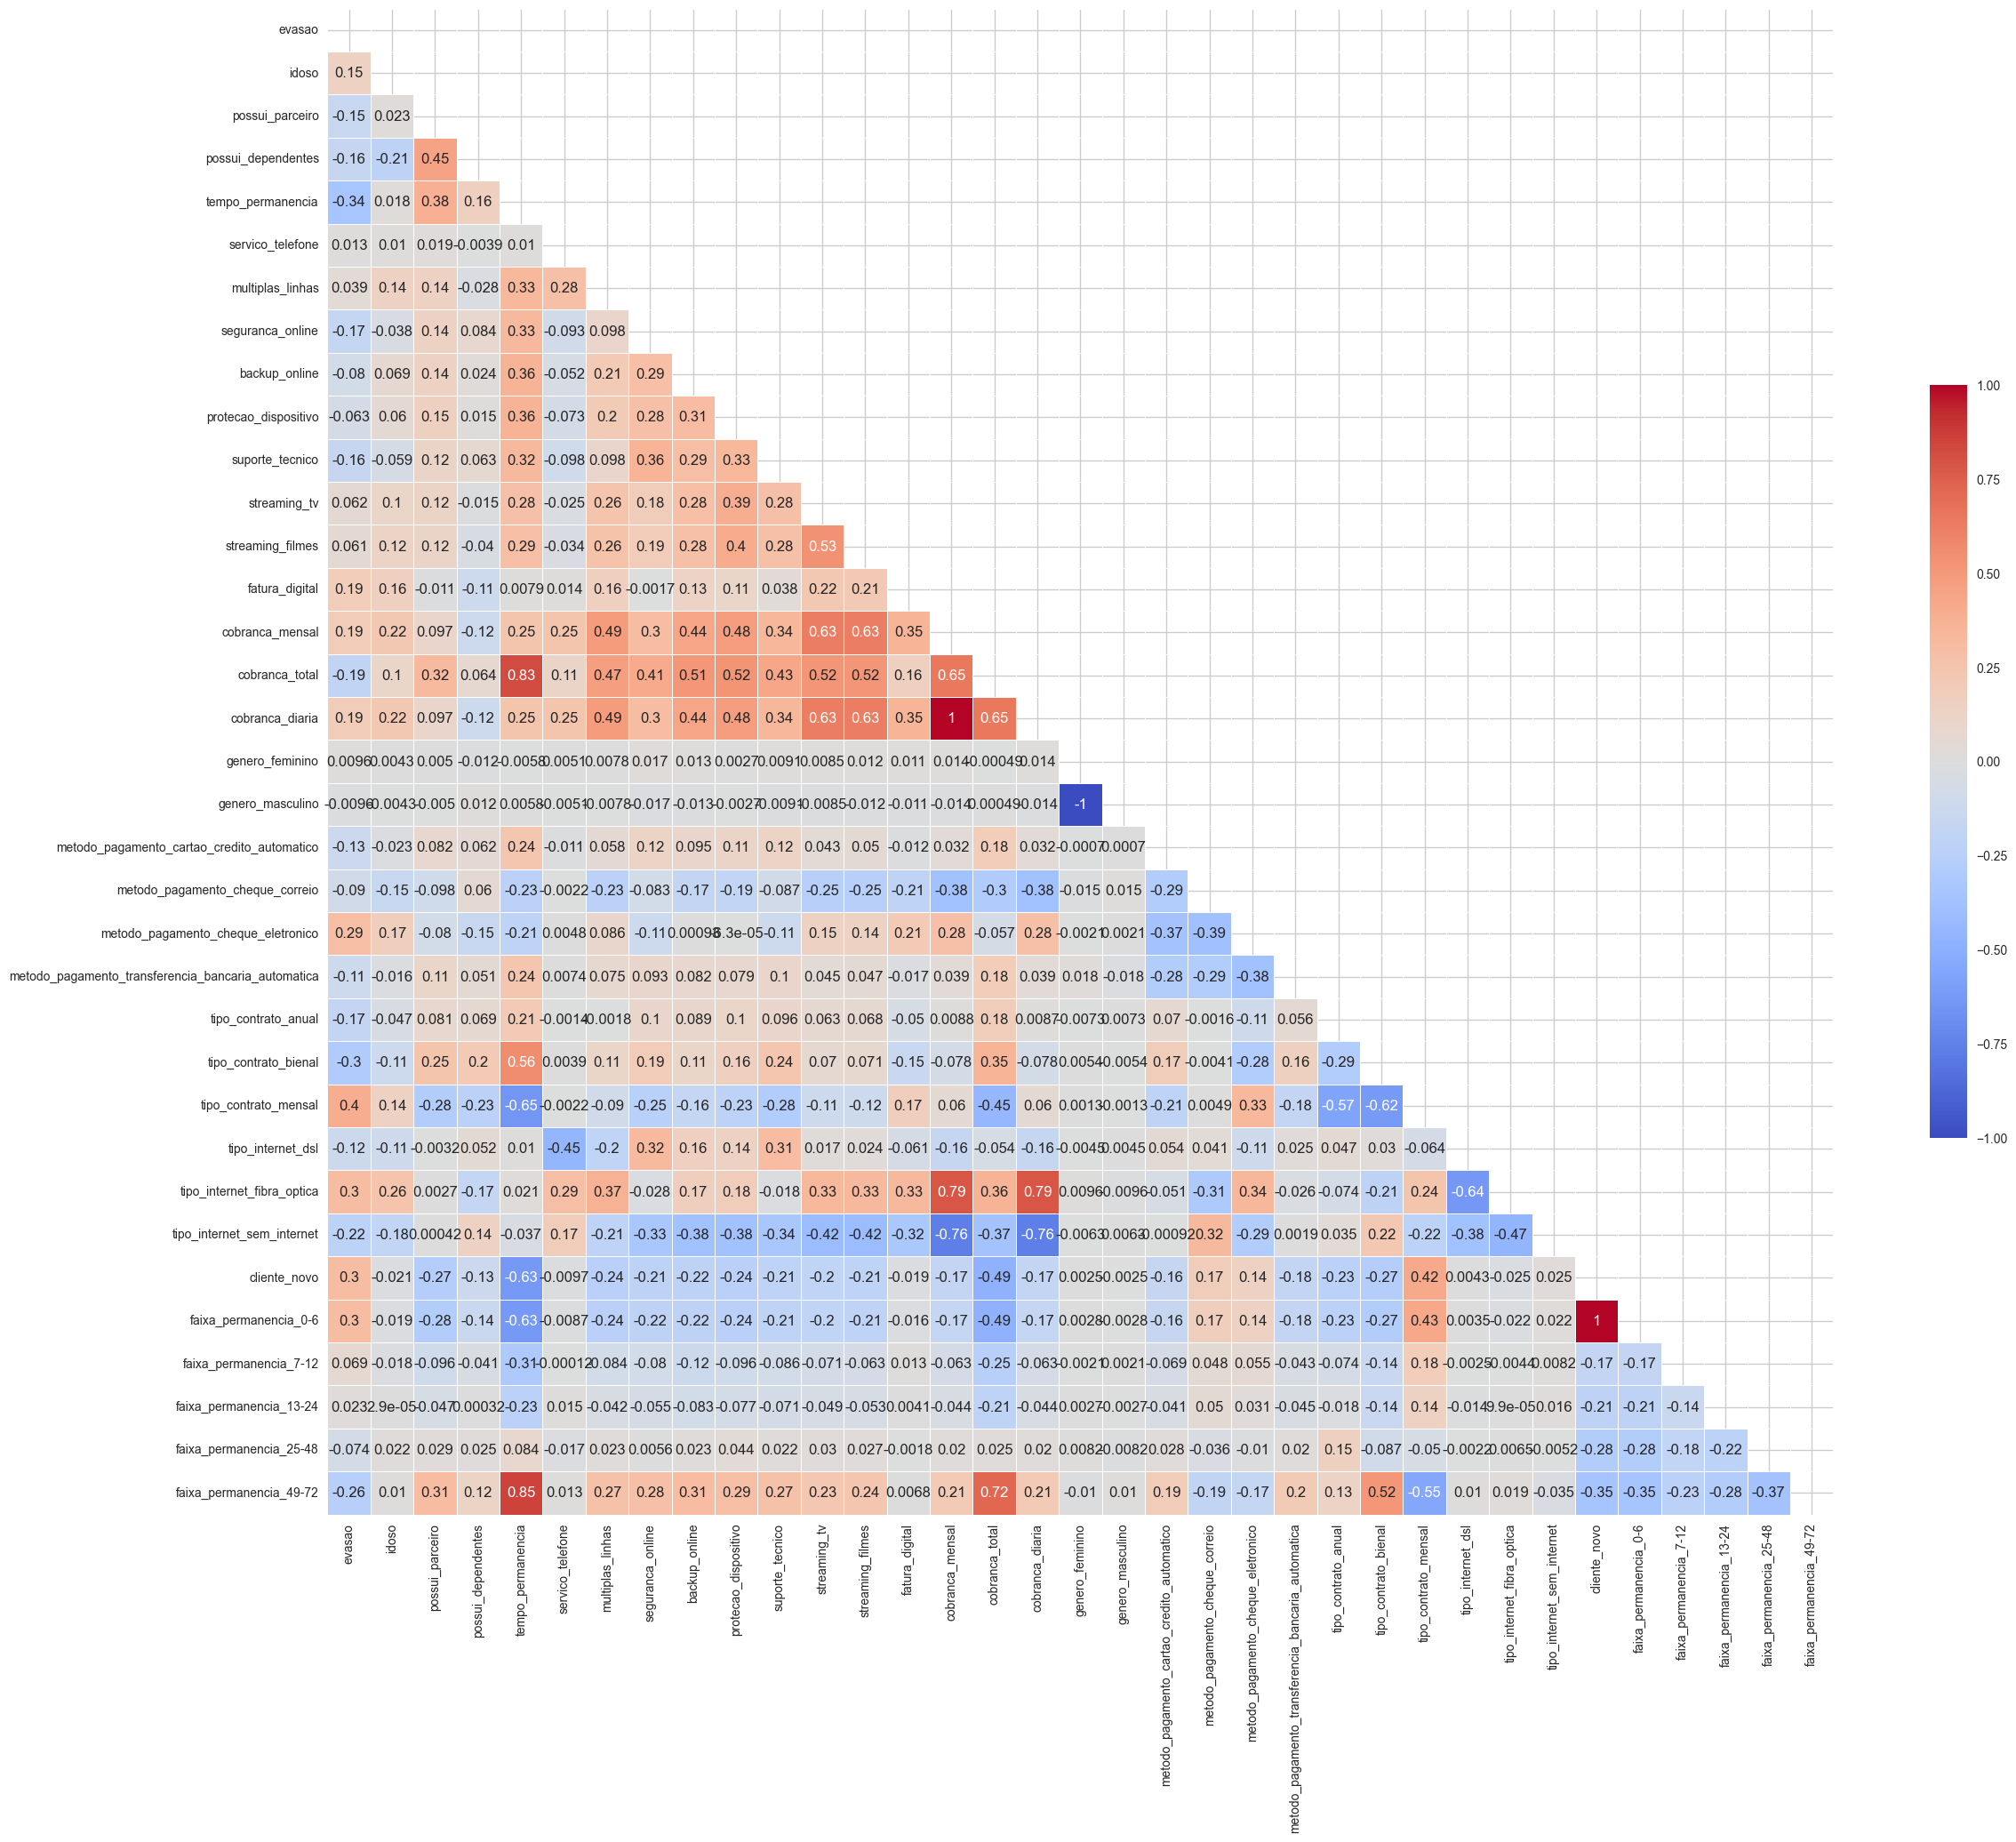

In [112]:
graph_corr()

Observa-se que a variável `tipo_contrato_mensal` apresenta correlação positiva moderada com ``evasao`` (0,39), indicando maior probabilidade de cancelamento entre clientes com contrato mensal. 

Além disso, clientes com até 6 meses de permanência (`faixa_permanencia_0-6`) também demonstram maior tendência à evasão (0,30), reforçando o padrão de churn precoce. 

A variável `tipo_internet_fibra_optica` apresentou correlação positiva moderada (0,30), sugerindo possível influência do tipo de serviço na decisão de cancelamento, aspecto que pode demandar análise adicional.

### Análises Direcionadas

In [113]:
df_clean.columns

Index(['evasao', 'idoso', 'possui_parceiro', 'possui_dependentes',
       'tempo_permanencia', 'servico_telefone', 'multiplas_linhas',
       'seguranca_online', 'backup_online', 'protecao_dispositivo',
       'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'fatura_digital',
       'cobranca_mensal', 'cobranca_total', 'cobranca_diaria',
       'genero_feminino', 'genero_masculino',
       'metodo_pagamento_cartao_credito_automatico',
       'metodo_pagamento_cheque_correio', 'metodo_pagamento_cheque_eletronico',
       'metodo_pagamento_transferencia_bancaria_automatica',
       'tipo_contrato_anual', 'tipo_contrato_bienal', 'tipo_contrato_mensal',
       'tipo_internet_dsl', 'tipo_internet_fibra_optica',
       'tipo_internet_sem_internet', 'cliente_novo', 'faixa_permanencia_0-6',
       'faixa_permanencia_7-12', 'faixa_permanencia_13-24',
       'faixa_permanencia_25-48', 'faixa_permanencia_49-72'],
      dtype='str')

### Separação de Dados

#### Treinamento do DummyClassifier

O treinamento do **DummyClassifier** serve como um modelo baseline extremamente simples para servir como sujeito de comparação. Se o meu modelo real não superar as métricas do **DummyClassifier**, então ele não está aprendendo nada útil.

In [114]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(['evasao'], axis=1)
y = df_clean['evasao']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [115]:
# teste para o parametro do DummyClassifier
# DummyClassifier(strategy="most_frequent")
# DummyClassifier(strategy="stratified")
# DummyClassifier(strategy="uniform")

from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy="stratified")
model_dummy.fit(X_train, y_train)
y_pred_dummy = model_dummy.predict(X_test)

In [116]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calcular_metricas_classificacao(y_test, y_pred):

    metricas = {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4)
    }

    return metricas

In [117]:
calcular_metricas_classificacao(y_test, y_pred_dummy)

{'Accuracy': 0.6274, 'Precision': 0.2555, 'Recall': 0.2583, 'F1 Score': 0.2569}

### Treinamento do RandomForestClassifier

####  Porque usar o RandomForestClassifier

O objetivo do projeto é identificar possiveis evasões onde eu espero a mensagem de 0 para clientes que não irão evadir e 1 para aqueles que irão, isso é classificação binária, portanto é problema de classificação onde 0 não evade e 1 evade

In [118]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(max_depth= 5, random_state=42, class_weight='balanced') 
#o Quando você usa: class_weight='balanced' o scikit-learn dá mais peso para a classe minoritária (churn).
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
calcular_metricas_classificacao(y_test, y_pred_rf)

{'Accuracy': 0.7441, 'Precision': 0.4919, 'Recall': 0.8013, 'F1 Score': 0.6096}

### Comparação entre o RandomForestClassifier e o DummyClassifier

| Modelo          | Accuracy  | Precision   | Recall      | F1 Score|
|-----------------|------|------|---------|---------------------|
| DummyClassifier | 0.5861 | 0.1892 | 0.2009 | 0.1949|
| RandomForestClassifier   | 0.7441 | 0.4919 | 0.8013  | 0.6096|

Depois do treinamento do modelo RandomForestClassifier, notei uma melhora muito boa em relação ao modelo baseline do DummyClassifier.

Esses resultados da tabela evidenciam que o RandomForestClassifier possui desempenho superior ao baseline, sendo capaz de realizar previsões mais precisas sobre a evasão de clientes.

### Validação Cruzada

A validação cruzada é uma técnica utilizada para avaliar a capacidade de generalização de um modelo de machine learning. Em vez de dividir os dados apenas uma vez em conjuntos de treino e teste, a validação cruzada realiza múltiplas divisões do conjunto de dados.

Para classificação desbalanceada (como churn), usarei o ``StratifiedKFold`` para que ele mantenha a proporção de classes em cada fold.


In [119]:
from sklearn.model_selection import StratifiedKFold, cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(model_rf, X_train, y_train, cv=cv, scoring=scoring )
cv_results

{'fit_time': array([0.25097251, 0.25887609, 0.25193262, 0.26246953, 0.33511281]),
 'score_time': array([0.01736975, 0.01737857, 0.01957703, 0.01751542, 0.01727533]),
 'test_accuracy': array([0.74862385, 0.76422018, 0.73944954, 0.73394495, 0.7412844 ]),
 'test_precision': array([0.51029748, 0.52863436, 0.49884527, 0.49247312, 0.50219298]),
 'test_recall': array([0.78798587, 0.84805654, 0.76325088, 0.80918728, 0.80633803]),
 'test_f1': array([0.61944444, 0.65128901, 0.60335196, 0.61229947, 0.61891892])}

#### Para melhor ver o resultado da validação cruzada, transformei o resultado em um DataFrame

In [120]:
df_cv_results = pd.DataFrame(cv_results)
df_cv_results

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.250973,0.017370,0.748624,0.510297,0.787986,0.619444
1,0.258876,0.017379,0.764220,0.528634,0.848057,0.651289
2,0.251933,0.019577,0.739450,0.498845,0.763251,0.603352
3,0.262470,0.017515,0.733945,0.492473,0.809187,0.612299
4,0.335113,0.017275,0.741284,0.502193,0.806338,0.618919


In [121]:
metricas = df_cv_results[['test_accuracy','test_precision','test_recall','test_f1']].describe().reset_index()
metricas

,index,test_accuracy,test_precision,test_recall,test_f1
0,count,5.000000,5.000000,5.000000,5.000000
1,mean,0.745505,0.506489,0.802964,0.621061
2,std,0.011706,0.013949,0.031165,0.018106
3,min,0.733945,0.492473,0.763251,0.603352
4,25%,0.739450,0.498845,0.787986,0.612299
5,50%,0.741284,0.502193,0.806338,0.618919
6,75%,0.748624,0.510297,0.809187,0.619444
7,max,0.764220,0.528634,0.848057,0.651289


In [122]:
for metric in scoring.keys():

    scores = cv_results[f'test_{metric}']

    print(f"\n{metric.upper()}")
    print("Scores:", [f"{s:.3f}" for s in scores])
    print(f"Média: {scores.mean():.3f}")
    print(f"Std: {scores.std():.3f}")
    print("-"*50)


ACCURACY
Scores: ['0.749', '0.764', '0.739', '0.734', '0.741']
Média: 0.746
Std: 0.010
--------------------------------------------------

PRECISION
Scores: ['0.510', '0.529', '0.499', '0.492', '0.502']
Média: 0.506
Std: 0.012
--------------------------------------------------

RECALL
Scores: ['0.788', '0.848', '0.763', '0.809', '0.806']
Média: 0.803
Std: 0.028
--------------------------------------------------

F1
Scores: ['0.619', '0.651', '0.603', '0.612', '0.619']
Média: 0.621
Std: 0.016
--------------------------------------------------


### Avaliação do Modelo RandomForestClassifier - Balanced

___
Aqui, verifico a variança do Desvio Padrão dos ``folds`` a fim de identificar se os valores são altos ou baixos e determino a partir deles se o meu modelo é instavel ou consistente e também avalio a média dos``Folds`` 


1️⃣ **Accuracy = 0.746**

 - O modelo acerta cerca de 74% das previsões. Mas em problemas de churn, **accuracy** não é a melhor métrica, porque normalmente há desbalanceamento de classes.Por isso precisamos olhar **recall** e **precision**.

🎯 **Precision = 0.506**

- Entre todos os clientes que o modelo prevê como churn, ele acerta 50.6%. Isso significa que a equipe de retenção vai abordar alguns clientes que não cancelariam.

⚠️ **Recall = 0.803**

- Ele detecta 80.3% dos churns reais. Para problemas de retenção isso é excelente, porque a empresa consegue detectar a maioria dos clientes que poderiam ser perdidos.

⚖️ **F1 Score = 0.621**

- Isso indica que equilíbrio entre ``precision`` e ``recall`` relatando que o modelo razoável

---
#### 🧠 **Insight para o Negócio**

Portanto, o modelo ``RandomForestClassifier`` é bastante agressivo para detectar evasão (``churn``)
Isso é geralmente desejável em problemas de idetificação churn, porque:

"é melhor abordar clientes que não cancelariam
do que perder clientes que cancelariam"

In [123]:
y_pred_model_balanced  = model_rf.predict(X_test)
y_pred_model_balanced

array([1, 0, 0, ..., 0, 1, 0], shape=(1817,))

In [124]:
comparacao = pd.DataFrame({
    'Real': y_test,
    'Previsão de churn': y_pred_model_balanced
})

comparacao.head(10)

,Real,Previsão de churn
1414,0,1
4610,0,0
2862,0,0
4078,0,0
3964,1,1
3542,0,0
6011,0,1
5239,1,1
3815,0,1
468,0,1


In [125]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_model_balanced))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1364
           1       0.49      0.80      0.61       453

    accuracy                           0.74      1817
   macro avg       0.70      0.76      0.71      1817
weighted avg       0.81      0.74      0.76      1817



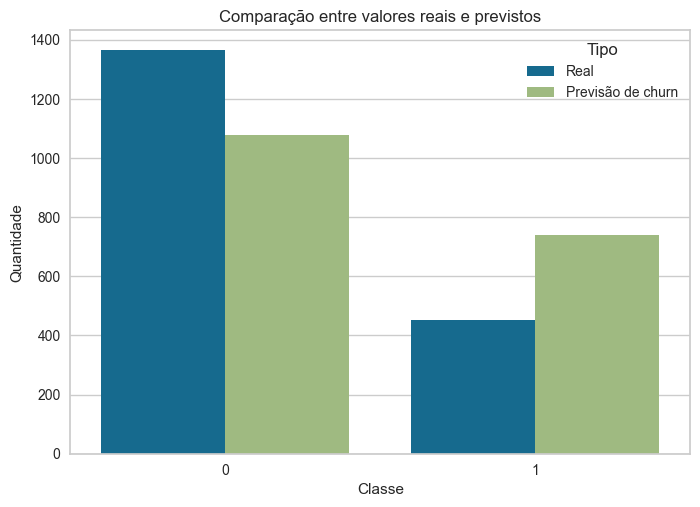

In [126]:
comparacao_melt = comparacao.melt(var_name='Tipo', value_name='Valor')

sns.countplot(data=comparacao_melt, x='Valor', hue='Tipo')

plt.title('Comparação entre valores reais e previstos')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

plt.show()

No Grafico acima, é mostrado a performance do modelo de previsão comparado ao dado real evidenciando a escolha do modelo em prever mais casos de ``churns`` do que ``não churns``

### Otimização de Hiperparâmetros

#### Seleção de recursos

c:\Users\User\OneDrive\Área de Trabalho\Faculdade\Alura\challenge3-data-science-main\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


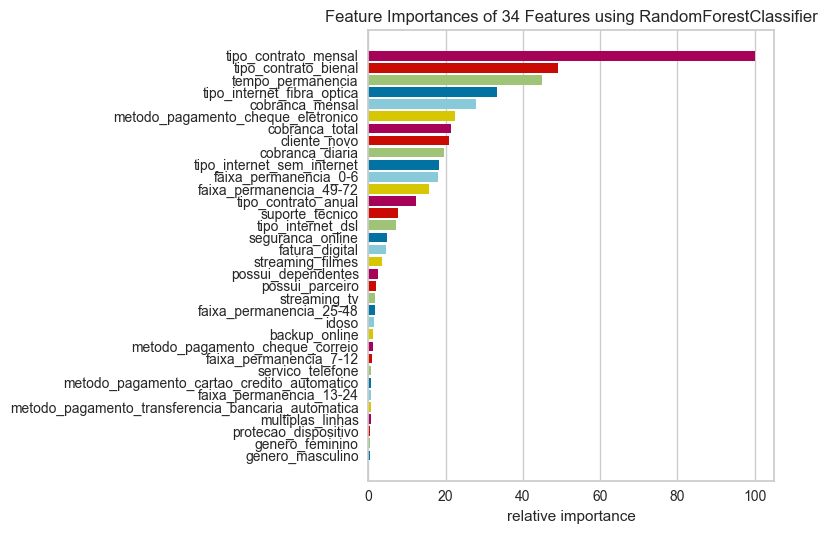

<Axes: title={'center': 'Feature Importances of 34 Features using RandomForestClassifier'}, xlabel='relative importance'>

In [127]:
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(model_rf)
viz.fit(X_train, y_train)

viz.show()

c:\Users\User\OneDrive\Área de Trabalho\Faculdade\Alura\challenge3-data-science-main\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


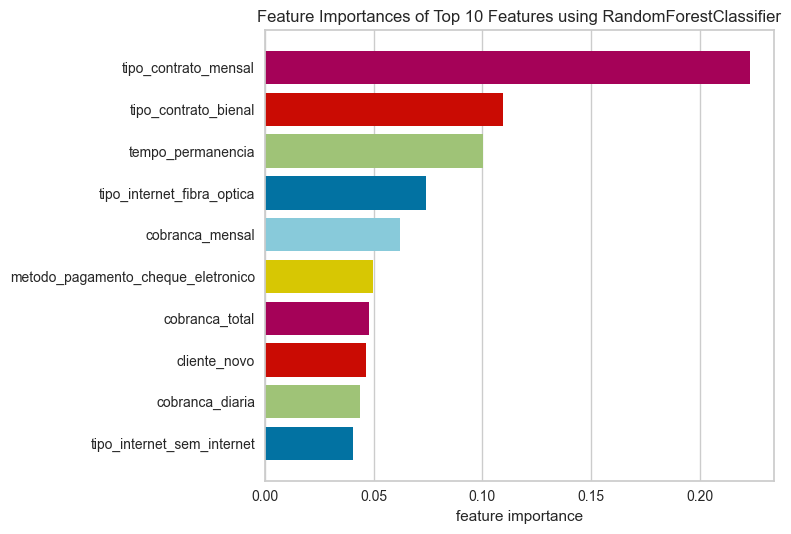

<Axes: title={'center': 'Feature Importances of Top 10 Features using RandomForestClassifier'}, xlabel='feature importance'>

In [128]:
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(model_rf, relative=False, topn=10)
viz.fit(X_train, y_train)
        
viz.show()
        

#### Para gerar um visual que mostre a relação entre evasão e tipo de contrato, será feito...

In [129]:
df_plot = df_clean.copy() # Para não interferir no Df principal, fiz um copy() do DataFrame

In [130]:
tipo_contrato = [['tipo_contrato_mensal', 'tipo_contrato_bienal', 'tipo_contrato_anual']]

In [131]:
# Cria coluna 'tipo_contrato' a partir das dummies
df_plot['tipo_contrato'] = df_plot[['tipo_contrato_mensal', 
                                      'tipo_contrato_bienal', 
                                      'tipo_contrato_anual']].idxmax(axis=1)

# Remove o prefixo se quiser só o tipo
df_plot['tipo_contrato'] = df_plot['tipo_contrato'].str.replace('tipo_contrato_', '')

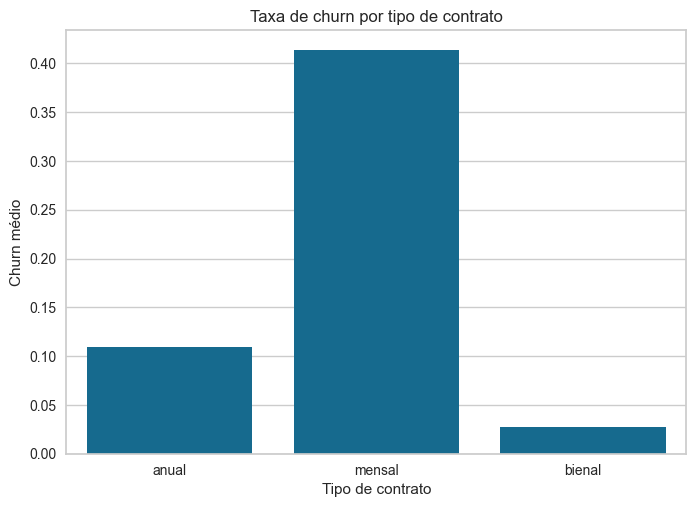

In [132]:
sns.barplot(
    data=df_plot,
    x='tipo_contrato',
    y='evasao',  # 0 ou 1
    estimator='mean',  # média → taxa de churn
    errorbar=None
)

plt.title("Taxa de churn por tipo de contrato")
plt.ylabel("Churn médio")
plt.xlabel("Tipo de contrato")
plt.show()

In [133]:
# Obtém importâncias do Random Forest
importances = model_rf.feature_importances_

# Cria DataFrame com features e suas importâncias
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,  # use X_train se for o conjunto de treino
    'Importance': importances
})

# Ordena do maior para o menor
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Exibe as top 10 features
print(feature_importances.head(10))

                               Feature  Importance
24                tipo_contrato_mensal    0.222999
23                tipo_contrato_bienal    0.109529
3                    tempo_permanencia    0.100171
26          tipo_internet_fibra_optica    0.074163
13                     cobranca_mensal    0.062239
20  metodo_pagamento_cheque_eletronico    0.049867
14                      cobranca_total    0.047731
28                        cliente_novo    0.046575
15                     cobranca_diaria    0.043681
27          tipo_internet_sem_internet    0.040440


In [134]:
def feat_import_graph():
    import matplotlib.cm as cm

    # Criar DataFrame das importâncias
    importances = model_rf.feature_importances_
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    })

    # Ordenar e pegar top 10
    top_features = feature_importances.sort_values(by='Importance', ascending=False).head(10)

    # Gradiente de cores
    norm = plt.Normalize(top_features['Importance'].min(), top_features['Importance'].max())
    colors = cm.viridis(norm(top_features['Importance']))

    # Criar figura e ax
    fig, ax = plt.subplots(figsize=(10,6))
    bars = ax.barh(top_features['Feature'], top_features['Importance']*100, color=colors)
    ax.invert_yaxis()  # mais importante no topo

    # Adicionar valores no topo das barras
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%', ha='left', va='center', fontsize=10)

    # Ajustes visuais
    ax.set_title('Top 10 Features – Importância na Evasão', fontsize=16, weight='bold')
    ax.set_ylabel('Features', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)

    # ✅ Remove todos os ticks do eixo x
    ax.set_xticks([])


    plt.tight_layout()
    return plt

<module 'matplotlib.pyplot' from 'c:\\Users\\User\\OneDrive\\Área de Trabalho\\Faculdade\\Alura\\challenge3-data-science-main\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

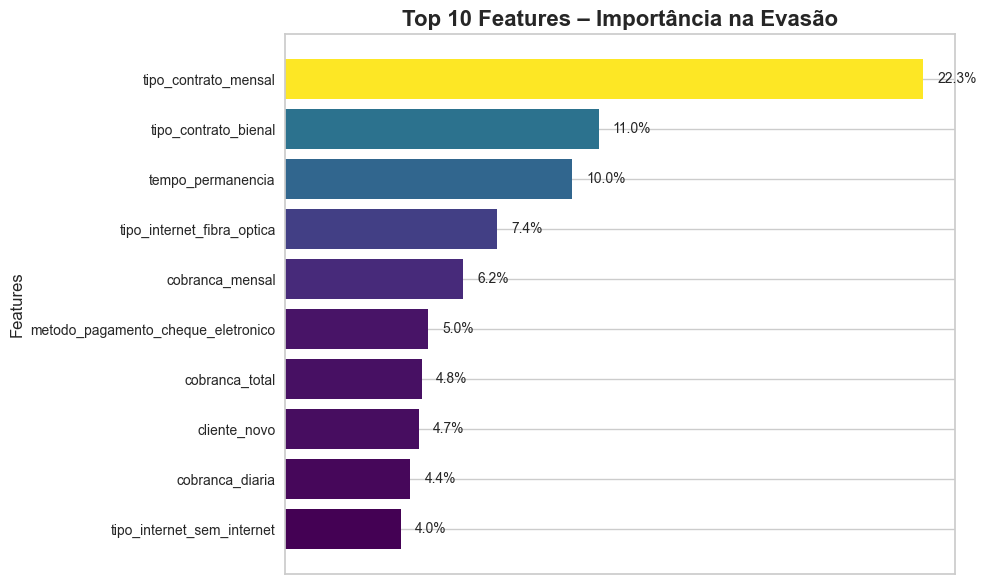

In [135]:
feat_import_graph()

## 📊  Análise de Importância das Variáveis do Modelo RandomForest


---

### 📈 Top 5 Features mais importantes

| Rank | Feature | Importance | Interpretação |
|------|---------|-----------|---------------|
| 1 | `tipo_contrato_mensal` | 0.223 | Clientes com contrato mensal têm **maior propensão a evadir**. |
| 2 | `tipo_contrato_bienal` | 0.110 | Contratos bienais reduzem a evasão, mas ainda influenciam. |
| 3 | `tempo_permanencia` | 0.100 | Quanto maior o tempo de permanência, menor a chance de churn. |
| 4 | `tipo_internet_fibra_optica` | 0.074 | Clientes com fibra óptica têm comportamento específico de retenção. |
| 5 | `cobranca_mensal` | 0.062 | Forma de cobrança mensal influencia a evasão. |


**🔑 Observação:** Estas 5 features concentram quase 57% da importância total do modelo, sendo decisivas para a previsão.

---

### 🔹 Outros fatores relevantes

- `metodo_pagamento_cheque_eletronico` (0.050)  
- `cobranca_total` (0.048)  
- `cliente_novo` (0.047)  
- `faixa_permanencia_0-6` (0.040)  
- `tipo_internet_sem_internet` (0.040)  

> Indicam que métodos de pagamento, clientes novos e primeiros meses de contrato são fatores importantes no risco de churn.

---

### 🔹 Fatores com menor importância

- `genero_feminino` / `genero_masculino` (~0.00087)  
- Serviços opcionais (`streaming_tv`, `protecao_dispositivo`)  
- Características demográficas (`idoso`, `possui_parceiro`)  

> Esses fatores isolados têm **baixo impacto** no modelo.

---

### 💡 Interpretação Estratégica

1. **Priorizar contratos mensais**  
   - Criar campanhas de retenção para reduzir churn nos primeiros 6 meses.

2. **Foco em onboarding e clientes novos**  
   - Implementar programas de engajamento inicial para `cliente_novo`.

3. **Atenção à forma de cobrança**  
   - Cobrança mensal ou cheque eletrônico são fatores de risco → oferecer opções mais flexíveis.

4. **Fidelização pelo tempo de permanência**  
   - Estratégias devem focar na retenção inicial para aumentar o tempo médio de permanência.

5. **Serviços de internet**  
   - Avaliar impacto da qualidade e disponibilidade do serviço (`fibra_optica` e `sem_internet`) na evasão.

### **Analise Direcionada**

Farei agora uma analise direcionada aos dados para encontrar padrões e comportamentos, agora com o direcionamento correto para as Variaveis de maior importância

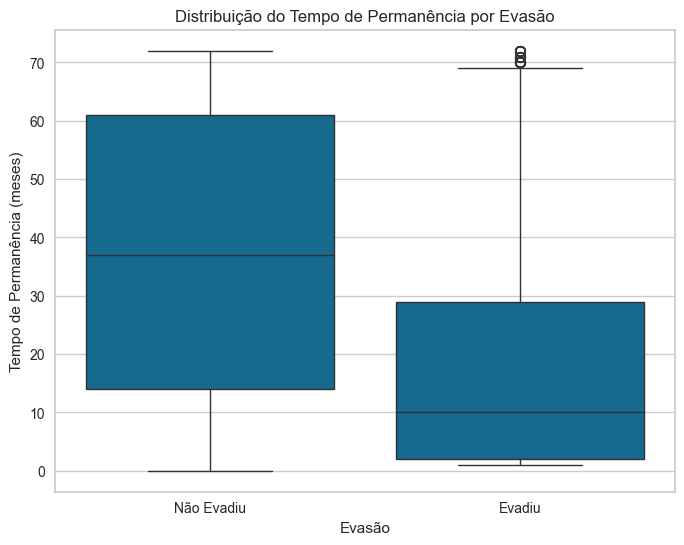

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x='evasao',               # 0 ou 1
    y='tempo_permanencia'
)

plt.xticks([0,1], ['Não Evadiu', 'Evadiu'])
plt.title("Distribuição do Tempo de Permanência por Evasão")
plt.ylabel("Tempo de Permanência (meses)")
plt.xlabel("Evasão")
plt.show()

O boxplot indicou que as evasões começam aproximadamente a partir do **segundo mês de permanência**, ou seja, os primeiros meses são críticos para determinar evasão
 

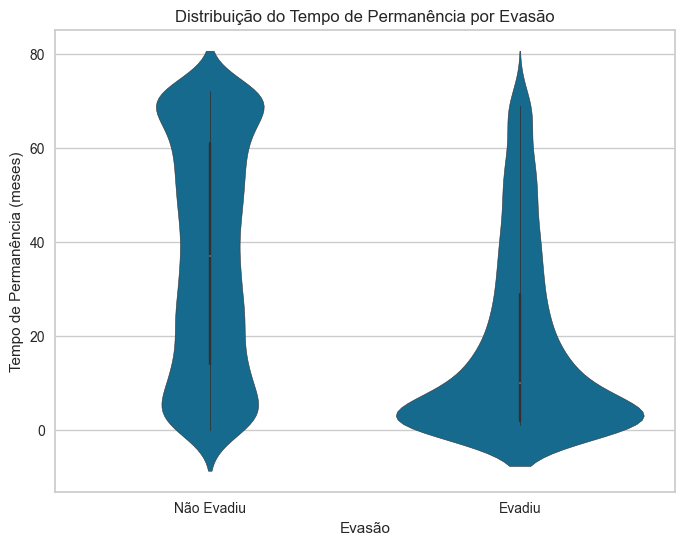

In [137]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df_clean,
    x='evasao',
    y='tempo_permanencia'
)

plt.xticks([0,1], ['Não Evadiu', 'Evadiu'])
plt.title("Distribuição do Tempo de Permanência por Evasão")
plt.ylabel("Tempo de Permanência (meses)")
plt.xlabel("Evasão")
plt.show()

 O ``violinplot`` consegue representar melhor a taxa de evasão nos primeiros meses

In [138]:
# Criar cópia só para plot
df_plot = df_clean.copy()

# Criar coluna categórica a partir das dummies
df_plot['faixa_permanencia'] = df_plot[['faixa_permanencia_0-6',
                                        'faixa_permanencia_7-12',
                                        'faixa_permanencia_13-24',
                                        'faixa_permanencia_25-48',
                                        'faixa_permanencia_49-72']].idxmax(axis=1)

# Remover prefixo
df_plot['faixa_permanencia'] = df_plot['faixa_permanencia'].str.replace('faixa_permanencia_', '')

df_plot['tipo_contrato'] = df_plot[['tipo_contrato_mensal', 
                                      'tipo_contrato_bienal', 
                                      'tipo_contrato_anual']].idxmax(axis=1)

# Remove o prefixo se quiser só o tipo
df_plot['tipo_contrato'] = df_plot['tipo_contrato'].str.replace('tipo_contrato_', '')

In [139]:
df_plot.head()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_internet_fibra_optica,tipo_internet_sem_internet,cliente_novo,faixa_permanencia_0-6,faixa_permanencia_7-12,faixa_permanencia_13-24,faixa_permanencia_25-48,faixa_permanencia_49-72,faixa_permanencia,tipo_contrato
0,0,0,1,1,9,1,0,0,1,0,...,0,0,0,0,1,0,0,0,7-12,anual
1,0,0,0,0,9,1,1,0,0,0,...,0,0,0,0,1,0,0,0,7-12,mensal
2,1,0,0,0,4,1,0,0,0,1,...,1,0,1,1,0,0,0,0,0-6,mensal
3,1,1,1,0,13,1,0,0,1,1,...,1,0,0,0,0,1,0,0,13-24,mensal
4,1,1,1,0,3,1,0,0,0,0,...,1,0,1,1,0,0,0,0,0-6,mensal


In [140]:
import pandas as pd

def faixa_perm_contrato():
    # Agrupar e calcular média
    df_agg = df_plot.groupby(['faixa_permanencia', 'tipo_contrato'])['evasao'].mean().reset_index()

    # Plotagem do gráfico
    plt.figure(figsize=(10,6))

    ax = sns.barplot(
        data=df_agg,
        x='faixa_permanencia',
        y='evasao',
        hue='tipo_contrato',
        ci=None,
        palette={'mensal':'#e23155', 'anual':'#203f75', 'bienal':'#96bfb9'}
    )

    # Remover o rótulo e ticks do eixo y
    ax.set_ylabel('')
    ax.set_yticks([])

    plt.title("Taxa de evasão por faixa de permanência e tipo de contrato", fontsize=16)
    plt.xlabel("Faixa de permanência (meses)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Valores em cima das barras como porcentagem
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height*100:.1f}%',  # multiplica por 100 e adiciona %
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0,3),
                    textcoords='offset points')

    plt.legend(title='Tipo de contrato')
    return plt

C:\Users\User\AppData\Local\Temp\ipykernel_15644\2465411158.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


<module 'matplotlib.pyplot' from 'c:\\Users\\User\\OneDrive\\Área de Trabalho\\Faculdade\\Alura\\challenge3-data-science-main\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

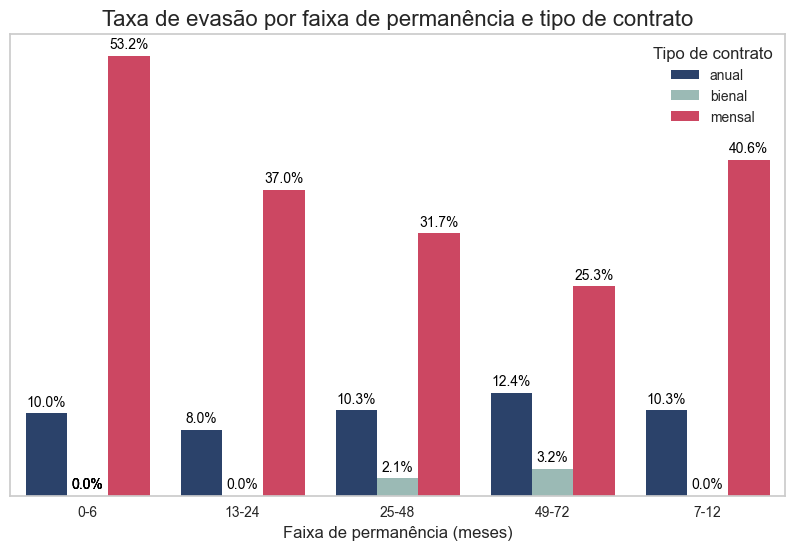

In [141]:
faixa_perm_contrato()

Agora com o Gráfico de barras demonstra a taxa de evasão por tipo de contrato e fica fácil identificar a alta taxa de evasão na faixa de permanência de 0-6 meses por tipo de contrato mensal.


- O gráfico evidencia que os **primeiros 6 meses são críticos**, especialmente para contratos mensais. **Estratégias de retenção focadas** nesse período e incentivos para contratos mais longos podem reduzir significativamente a evasão inicial e aumentar a estabilidade da base de clientes.

###  💡 Estratégias recomendadas

**1.** Promoções ou descontos para contratos mais longos

- Incentivar novos clientes a escolher contratos **bienais** ou **anuais**, tipos de contrato com taxa menores de evasão, reduzindo a vulnerabilidade da faixa inicial de 0-6 meses.

**2.** Segmentação por perfil do cliente

- Combinar com dados demográficos, serviços contratados e método de pagamento para identificar grupos de maior risco.

- Por exemplo: clientes novos, sem dependentes, ou sem serviço adicional podem ter maior propensão a cancelar.

---
### Otimizando os hiperparâmetros com o modelo GridSearchCV

In [142]:
param_grid = {
    'max_depth' : [5, 10, 15],
    'min_samples_leaf' :[1, 2, 3],
    'min_samples_split' : [2, 4, 6],
    'n_estimators' : [100, 150, 200]
}

In [143]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=cv
)

model_grid.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
y_pred_model_grid  = model_grid.predict(X_test)
y_pred_model_grid

array([1, 0, 0, ..., 0, 0, 0], shape=(1817,))

In [ ]:
comparacao_grid = pd.DataFrame({
    'Real': y_test,
    'Previsão de churn': y_pred_model_grid
})

comparacao.head(10)

,Real,Previsão de churn
1414,0,1
4610,0,0
2862,0,0
4078,0,0
3964,1,1
3542,0,0
6011,0,1
5239,1,1
3815,0,1
468,0,1


In [ ]:
comparacao_grid.value_counts()

Real  Previsão de churn
0     0                    1247
1     1                     228
      0                     225
0     1                     117
Name: count, dtype: int64

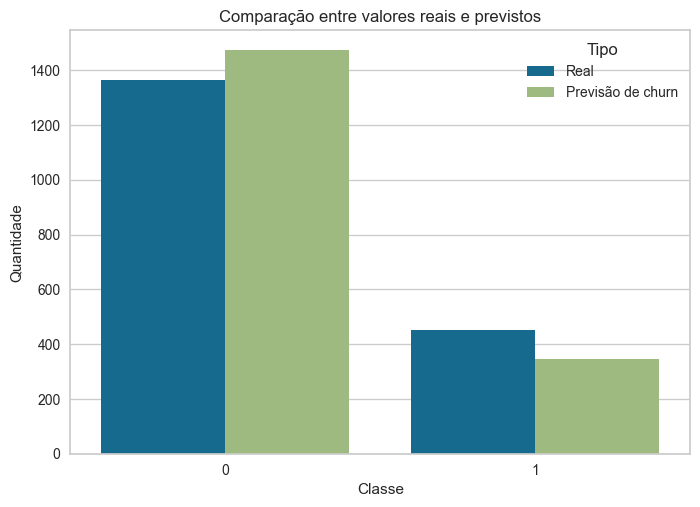

In [ ]:
comparacao_melt = comparacao_grid.melt(var_name='Tipo', value_name='Valor')

sns.countplot(data=comparacao_melt, x='Valor', hue='Tipo')

plt.title('Comparação entre valores reais e previstos')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

plt.show()

In [ ]:
metricas_model_grid = calcular_metricas_classificacao(y_test, y_pred_model_grid)
metricas_model_grid

{'Accuracy': 0.8118, 'Precision': 0.6609, 'Recall': 0.5033, 'F1 Score': 0.5714}

### Avaliação do Modelo RandomForest com a otimização de GridSearchCV

Usando o GridSearchCV, o modelo encontrou hiperparâmetros melhores.

---

1️⃣ **Accuracy = 0.8118**

- Maior que os outros modelos. Mas para churn accuracy não é a métrica principal.

🎯 **Precision = 0.6609**

- Entre todos os clientes previstos como churn: Isso é bom, pois evita muitos falsos alarmes.

⚠️ **Recall = 0.5033**

- O modelo detecta 50% dos clientes que realmente cancelam porém é pior que o modelo balanceado

⚖️ **F1 Score = 0.5714**

- O F1 equilibra precision e recall.
___

#### **🧠 Insight importante**

Se prefirir detectar o máximo de churn: escolho ``modelo balanced`` 
- Porque: ``Recall`` = 0.803

Se preferir evitar falsos alarmes: escolho ``modelo GridSearch``
- Porque: ``Precision`` maior

___
Como na tabela de comparação abaixo:

| Modelo                     | Accuracy   | Precision | Recall    | F1        |
| -------------------------- | ---------- | --------- | --------- | --------- |
| Random Forest balanced     | 0.746      | 0.506     | **0.803** | **0.621** |
| Random Forest + GridSearch | **0.8118** | **0.6609**    | 0.5033    | 0.5714    |


## Treinando o Modelo KNN

Com os dados ja normalizados em ``df_clean``, utilizarei o modelo ``KNN`` para trabalhar no Dataframe com o objetivo de comparar os resultados de previsão com o primeiro modelo treinado ``RandomForestClassifier``.

Por abordar um problema de classificação e não de Regressão, acredito que o modelo ``KNN`` é a melhor opção entre os modelos estudados por mim de Machine Learning para esse caso.

In [ ]:
df_clean.head()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_permanencia,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_contrato_mensal,tipo_internet_dsl,tipo_internet_fibra_optica,tipo_internet_sem_internet,cliente_novo,faixa_permanencia_0-6,faixa_permanencia_7-12,faixa_permanencia_13-24,faixa_permanencia_25-48,faixa_permanencia_49-72
0,0,0,1,1,9,1,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
1,0,0,0,0,9,1,1,0,0,0,...,1,1,0,0,0,0,1,0,0,0
2,1,0,0,0,4,1,0,0,0,1,...,1,0,1,0,1,1,0,0,0,0
3,1,1,1,0,13,1,0,0,1,1,...,1,0,1,0,0,0,0,1,0,0
4,1,1,1,0,3,1,0,0,0,0,...,1,0,1,0,1,1,0,0,0,0


## Dividindo os dados entre treino e teste

In [ ]:
from sklearn.model_selection import train_test_split

x = df_clean.drop(['evasao'], axis=1)
y = df_clean['evasao']

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify = y,  random_state = 5)

### Previnindo valores nulos no Dataframe

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

x_treino = imputer.fit_transform(x_treino)
x_teste = imputer.transform(x_teste)

## KNN

#### Normalizando os dados

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [ ]:
x_treino_norm = pd.DataFrame(x_treino_normalizado)
x_treino_norm

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,0.0,1.0,1.0,0.944444,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.541667,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.180556,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.402778,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,1.0,0.0,0.097222,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5445,0.0,1.0,1.0,0.125000,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5446,0.0,1.0,1.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
5447,0.0,0.0,0.0,0.138889,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5448,0.0,0.0,1.0,0.486111,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
x_treino_norm.isna().any().sum()

np.int64(0)

#### Treinando o KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=9)

In [ ]:
knn.fit(x_treino_norm, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
x_teste_normalizado = normalizacao.transform(x_teste)

In [ ]:
y_pred = knn.predict(x_teste_normalizado)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1817,))

In [ ]:
metricas_dt = calcular_metricas_classificacao(y_teste, y_pred)
metricas_dt

{'Accuracy': 0.776, 'Precision': 0.5781, 'Recall': 0.4754, 'F1 Score': 0.5217}

### Avaliação do Modelo KNN

---

**📊 Accuracy = 0.776**

- O modelo acertou **77.6%** das previsões totais.

**🎯 Precision = 0.578**

- Quando o modelo prevê churn, ele acerta **57.8%** das vezes.

**⚠️ Recall = 0.475**

- Essa métrica é muito importante para churn, porém, o modelo identifica apenas **47.5%** dos clientes que realmente cancelam.

**⚖️ F1 Score = 0.5217**

- O F1 Score combina: ``Precision`` e ``Recall``. Esse valor indica que o modelo tem equilíbrio moderado entre detectar churn e evitar falsos positivos.

---

O modelo ``RandomForestClassifier`` apresentou um desempenho melhor ao ``KNN`` em todas as métricas avaliadas. Destacando especialmente na _precisão_ e no _F1 Score_, indicando maior capacidade de identificar corretamente clientes propensos ao churn enquanto reduz falsos positivos. Embora o ``KNN`` apresente desempenho razoável, o ``RandomForestClassifier`` demonstra maior capacidade de generalização e é mais adequado para o problema analisado

___

## 📊 Relatório Executivo – Previsão de Evasão de Clientes (Random Forest)

## 🎯 1. Objetivo

O objetivo deste projeto é **identificar clientes com maior risco de evasão (churn)** e gerar **insights estratégicos para retenção** a partir de um modelo de **Machine Learning**, antecipando cancelamentos e otimizando ações de fidelização.

---

## 🛠️ 2. Metodologia

1. **Dados analisados:**  
   - 👤 Demográficos: `idoso`, `possui_parceiro`, `possui_dependentes`, `genero`  
   - 📺 Serviços contratados: `streaming_tv`, `backup_online`, `streaming_filmes`, etc.  
   - 📃 Contratos: `mensal`, `anual`, `bienal`  
   - ⏱️ Faixas de permanência: `0-6`, `7-12`, `13-24`, `25-48`, `49-72` meses  
   - 🎯 Variável alvo: `evasao` (0 = não evadiu, 1 = evadiu)

2. **Pré-processamento:**  
   - Tratamento de valores nulos (`SimpleImputer`)  
   - Encoding de variáveis categóricas (`OneHotEncoder`)  
   - Normalização de variáveis numéricas (`StandardScaler`)  
   - Divisão treino/teste com `stratify=y`

3. **Modelagem:**  
   - Modelo principal: **Random Forest Classifier**  
   - Avaliação: ``Accuracy``, ``Precision``, ``Recall``, ``F1-score``
   - Cross-validation (``StratifiedKFold``) para robustez  

---

## 📈 3. Resultados – Feature Importance

### **Top 5 Features mais importantes**

| Rank | Feature | Importance | Interpretação |
|------|---------|-----------|---------------|
| 1 | `tipo_contrato_mensal` | 0.223 | Contratos mensais têm maior propensão a evasão. |
| 2 | `tipo_contrato_bienal` | 0.110 | Contratos bienais reduzem a evasão, mas ainda influenciam. |
| 3 | `tempo_permanencia` | 0.100 | Maior tempo de permanência → menor chance de churn. |
| 4 | `tipo_internet_fibra_optica` | 0.074 | Tipo de internet influencia retenção. |
| 5 | `cobranca_mensal` | 0.062 | Forma de cobrança impacta evasão. |

> 🔑 Observação: Essas 5 features concentram quase **57% da importância total**, sendo decisivas no modelo.

---

### **Outros fatores relevantes**

- `metodo_pagamento_cheque_eletronico` (0.050)  
- `cobranca_total` (0.048)  
- `cliente_novo` (0.047) → clientes novos têm maior risco  
- `faixa_permanencia_0-6` (0.040) → confirma que primeiros meses são críticos  
- `tipo_internet_sem_internet` (0.040) → falta de internet aumenta evasão  

### **Fatores com menor importância**

- Gênero (`genero_feminino`, `genero_masculino`)  
- Serviços opcionais (`streaming_tv`, `protecao_dispositivo`)  
- Características demográficas (`idoso`, `possui_parceiro`)  

> Esses fatores têm baixo impacto isolado no modelo.

---

## 💡 4. Interpretação Estratégica

1. **Priorizar contratos mensais**  
   - Desenvolver campanhas de retenção para reduzir churn nos primeiros 6 meses.  

2. **Foco em onboarding e clientes novos**  
   - Programas de engajamento inicial para `cliente_novo`.  

3. **Atenção à forma de cobrança**  
   - Cobrança mensal ou cheque eletrônico são fatores de risco → oferecer opções mais flexíveis.  

4. **Fidelização pelo tempo de permanência**  
   - Estratégias devem focar na retenção inicial para aumentar o tempo médio de permanência.  

5. **Serviços de internet**  
   - Avaliar impacto da qualidade e disponibilidade do serviço (`fibra_optica` e `sem_internet`) na evasão.

---

## 🏆 5. Conclusão

> A análise com Random Forest evidencia que **os primeiros meses de contrato, tipo de contrato e tempo de permanência** são os principais determinantes da evasão. 
 
> Estratégias de retenção focadas nesses fatores, combinadas com incentivos a contratos mais longos e melhorias nos serviços de internet, podem **reduzir significativamente a evasão** e aumentar a estabilidade da base de clientes, melhorando receita recorrente e previsibilidade do negócio.

---

## Salvando o modelo em arquivo ``.pkl``

In [ ]:
import pickle

In [ ]:
with open('modelo_rfb.pkl', 'wb') as arquivo:
    pickle.dump(model_rf, arquivo)

## Salvando Graficos de relatório 

In [144]:
def salvar_grafico(grafico, nome):
    imagem = grafico()
    imagem.savefig(f'{nome}.png', bbox_inches='tight')
    imagem.close()

# Substitua as chamadas de função e nomes conforme necessário
salvar_grafico(faixa_perm_contrato, 'faixa_perm_contrato')
salvar_grafico(graph_corr, 'grafico_correlacoes_')
salvar_grafico(feat_import_graph, 'grafico_importancia_categoria')


C:\Users\User\AppData\Local\Temp\ipykernel_15644\2465411158.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
